Optical Flow?
-  연속된 두 프레임 사이에서 픽셀이 어디로 움직였는지 계산
- 물체 속도 방향
- 자율주행, 드론, 동작인식


In [37]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow # Colab 환경에서 이미지 표시를 위한 함수 임포트
import time # 출력 속도를 조절하기 위한 time 모듈 임포트

video_path = '/content/drive/MyDrive/noooooooooooooo/Colab Notebooks/로키_부트캠프_AI응용/data/bird.mp4'

In [38]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error opening video file")
    exit()

In [39]:
# 프레임 재생 속도 조절 dealy (1000ms / 30fps = 33ms)

delay = int(1000 / 30)

# 추적 경로를 그리기 위한 random하게 색상 (200개 코너 점)
# 0-255 사이에서 3channel(BGR) 색상 200개 생성
color = np.random.randint(0, 255, (200,3))  # 0-255 사이에서 (200,3) 행렬을 만들어줘

lines = None    # 추적선 (이동경로) 그릴 이미지 저장 변수(초기화: 첫프레임)
prevImg = None  # 이전 프레임(직전에 나타난 이미지) 저장 변수(grayscaled image)

# calcOpticalFlowPyrLK() 중지 요건 설정 (Termination Criteria)
# (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 최대 반복 횟수(10), 오차 임계값(0.03))
# cv2.TERM_CRITERIA_EPS : 움직임이 0.03 px 미만 >> 수렴 (error 오차가 충분히 작아지면 멈추는 조건)
# cv2.TERM_CRITERIA_COUNT, 최대 반복(iteration) 횟수(10)

termcriteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
# termcriteria  # (3, 10, 0.03)

# 프레임 처리 개수 제한
frame_count = 0
MAX_FRAMES_TO_PROCESS = 150 # 최대 150 프레임만 처리
DISPLAY_EVERY_N_FRAMES = 20 # 20 프레임마다 결과 출력

print(f"광학 흐름 추적 시작 (최대 {MAX_FRAMES_TO_PROCESS} 프레임, {DISPLAY_EVERY_N_FRAMES} 프레임마다 출력)...")

광학 흐름 추적 시작 (최대 150 프레임, 20 프레임마다 출력)...


In [40]:
# 예제
'''
p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, gray, p0, None,
                                      winSize=(15,15),
                                      maxLevel=2,
                                      criteria=termcriteria)


cv2.calcOpticalFlowPyrLK (루카스-카나데 광학 흐름) 물체 이동 위치를 추적
old_gray, gray (grayscale한 이미지) 이전사진, 현재 사진
p0 : position 추적하고 싶은 점들의 좌표
None :  기본 설정
winSize=(15,15) 추적한 윈도우 사이즈 (주변 15*15 영역 비교 이동방향 계산)
maxLevel=2 이미지 피라미드 레벨 (영상 축소 단계 수)
criteria=termcriteria : 우리가 설정한 정지조건(기준) (최대 10번 또는 오차 0.03 미만)


p1: 추적된 새로운 좌표값 (position)
st: 추적 성공 여부 (1: 성공, 0: 실패) status
err: 추적 오류 (오차 정도) error


p0 (100, 200) 서있는 상태
p1 (50, 100)  오리걸음 하는 상태


st = 1 # 성공 (잘 추적했네)
err = 0.01 # 오차 거의 없네 (기준인 0.03 미만이니깐)
'''


'\np1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, gray, p0, None,\n                                      winSize=(15,15),\n                                      maxLevel=2,\n                                      criteria=termcriteria)\n\n\ncv2.calcOpticalFlowPyrLK (루카스-카나데 광학 흐름) 물체 이동 위치를 추적\nold_gray, gray (grayscale한 이미지) 이전사진, 현재 사진\np0 : position 추적하고 싶은 점들의 좌표\nNone :  기본 설정\nwinSize=(15,15) 추적한 윈도우 사이즈 (주변 15*15 영역 비교 이동방향 계산)\nmaxLevel=2 이미지 피라미드 레벨 (영상 축소 단계 수)\ncriteria=termcriteria : 우리가 설정한 정지조건(기준) (최대 10번 또는 오차 0.03 미만)\n\n\np1: 추적된 새로운 좌표값 (position)\nst: 추적 성공 여부 (1: 성공, 0: 실패) status\nerr: 추적 오류 (오차 정도) error\n\n\np0 (100, 200) 서있는 상태\np1 (50, 100)  오리걸음 하는 상태\n\n\nst = 1 # 성공 (잘 추적했네)\nerr = 0.01 # 오차 거의 없네 (기준인 0.03 미만이니깐)\n'

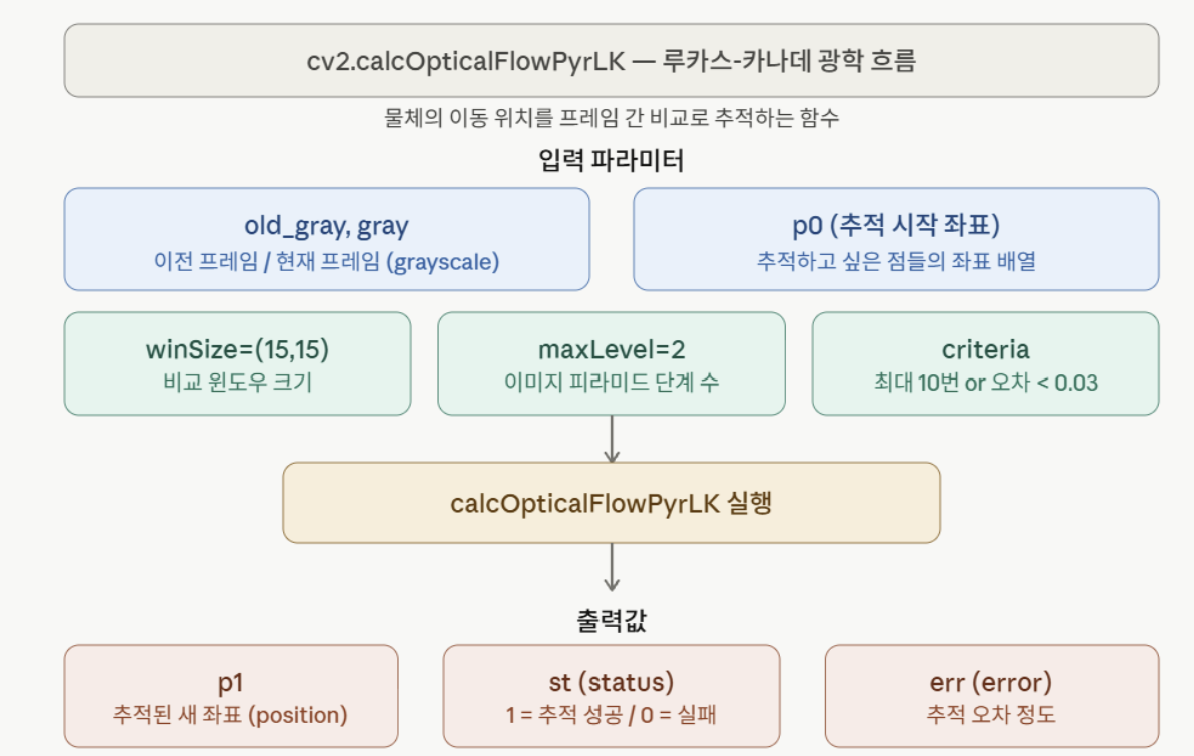

In [41]:
from cv2.gapi import imgproc
# 비디오 처리
while cap.isOpened() and frame_count < MAX_FRAMES_TO_PROCESS:
    ret, frame = cap.read()

    if not ret:
        break

    img_draw = frame.copy()
    # optical flow 계산하기 위해서 현재 프레임(사진)을 grayscale로 변환
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 최초 프레임 시작 (추적 시작)
    if prevImg is None:
        prevImg = gray # 현재 gray 이미지를 이전 이미지로 저장
        # 추적선 그릴 검은색 배경 이미지 생성(원본 프레임과 동일 크기)
        lines = np.zeros_like(frame)
        # Shi-Tomasi 코너 검출 알고리즘 (추적 시작할 코너점 200 개 검출)
        # (이전 이미지, 최대 코너점 수, 품질 임계값(0.01: 최고 코너 1%), 코너 간 최소거리 10px)
        prevPt = cv2.goodFeaturesToTrack(prevImg, 50, 0.01,10)
        # prevPt 코너 점 목록

    # 두번째 프레임 이후 처리(추적 진행 중)
    else:
        nextImg = gray  # 현재 gray 이미지를 다음 이미지로 저장

        # 루카스 카나데 optical flow
        nextPt, status, err = cv2.calcOpticalFlowPyrLK(prevImg, nextImg, prevPt, None, criteria=termcriteria)
        # prevImg: 이전 프레임(grayscale)
        # nextImg: 움직임을 찾아낼 현재(다음) 프레임
        # prevPt: 이전 프레임(prevImg) 추적할 점들의 좌표 있는 리스트
        # None: 다음 점들의 위치(nextPT) 미리 예측해서 넣어주기. 일반적으로 None 사용(컴퓨터가 알아서 해줌)
        # criteria=termcriteria: 언제까지 계산하고 멈출거야? (정지 조건)

        # 추적에 성공한 코너점(status == 1) 선별
        prevMv = prevPt[status == 1]    # 이전 프레임에서 추적 성공한 점
        nextMv = nextPt[status == 1]    # 현재 프레임에 대응하는 점

        # 추적 성공한 모든 쌍에 대해서 반복
        for i, (p, n) in enumerate(zip(prevMv, nextMv)):
            # 코너점 좌표 추출(배열 구조 해제)
            # 왜 하는거야? (귀찮은 듯)
            # >> OpenCV 때문이야 ex) [[130, 85]] >> [130, 85]
            px, py = p.ravel()
            nx, ny = n.ravel()

            # 이전 코너(p)와 새로운 코너(n) 사이에 추적선 그리기(lines 이미지에 누적)
            cv2.line(lines, (int(px), int(py)), (int(nx), int(ny)), color[i % len(color)].tolist(), 2)
            # 시작점 : 이전 위치(px, py), 끝점 (nx, ny)
            # color[i % len(color)].tolist() 코너 점 i 에 할당된 랜덤 색

            # 새로운 코너(n)에 원형 점 그리기(img_draw 이미지에 매 프레임마다 표시)
            cv2.circle(img_draw, (int(nx), int(ny)), 2, color[i % len(color)].tolist(), -1)

        # 누적된 추적선이 그려진 lines 이미지와 현재 프레임(img_draw)을 합성
        # >> 추적 경로가 비디오 프레임 위에 나타나요
        img_draw = cv2.add(img_draw, lines)

        # 다음 루프 위해서 현재 프레임(사진)과 코너점 >> 이전 변수로 이동
        prevImg = nextImg

        prevPt = nextMv.reshape(-1, 1, 2)
        # prevPt를 nextMv 형태로 맞춰 줘야 해요
        # (N, 2) >> (N, 1, 2)
        # -1: 자동 계산
        # 2: x,y 좌표

        # 원래 좌표 형식 [[x,y],[x,y],[x,y]]  shape (3,2) >>> (N,2)
        # OpenCV optical Flow 함수 입력 [[[x,y]],[[x,y]],[[x,y]]] shape (3,1,2) >> (N, 1, 2)
        # >> OpenCV 컨투어(윤과선) 기본적으로 (점의 개수, 1, 2)
        # >> 기본적 [행, 열, 채널] [N(데이터 개수), 1(열: 점 하나 하나(개별 데이터), 2(채널, 좌표 x,y))]

    # Colab 출력: 특정 간격의 프레임만 표시
    if frame_count % DISPLAY_EVERY_N_FRAMES == 0:
        print(f"\n--- Frame {frame_count} 광학 흐름 결과 ---")
        cv2_imshow(img_draw) # 추적 결과 프레임 표시
        time.sleep(1) # 출력이 빠르게 지나가는 것을 방지하기 위해 잠시 대기

    frame_count += 1
cap.release()


Output hidden; open in https://colab.research.google.com to view.